<a href="https://colab.research.google.com/github/Chaitanya15-ai/OIBSIP/blob/main/ChaitanyaSawant_task3(Level2_FraudDetection).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (134763, 31)

First 5 Rows
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.2

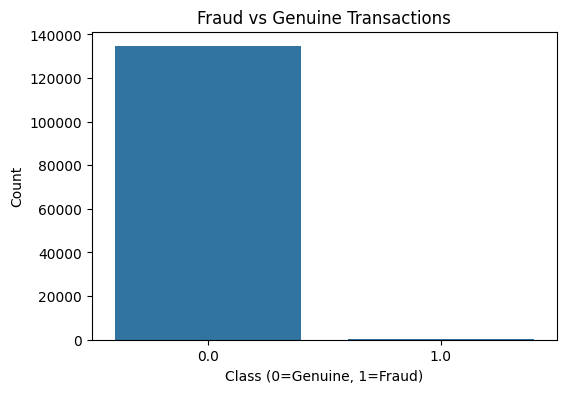

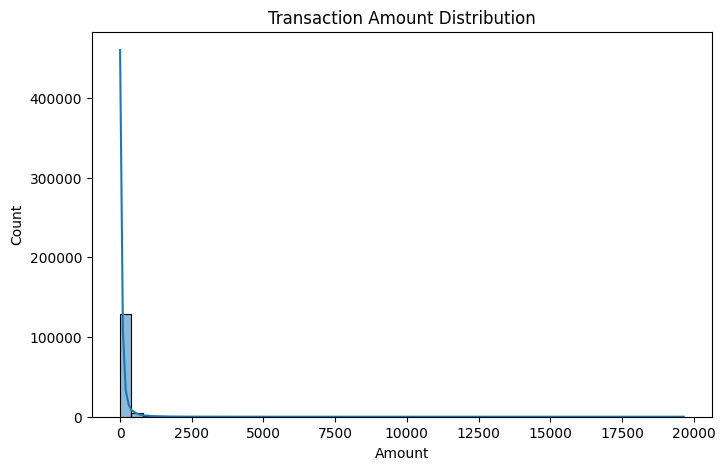

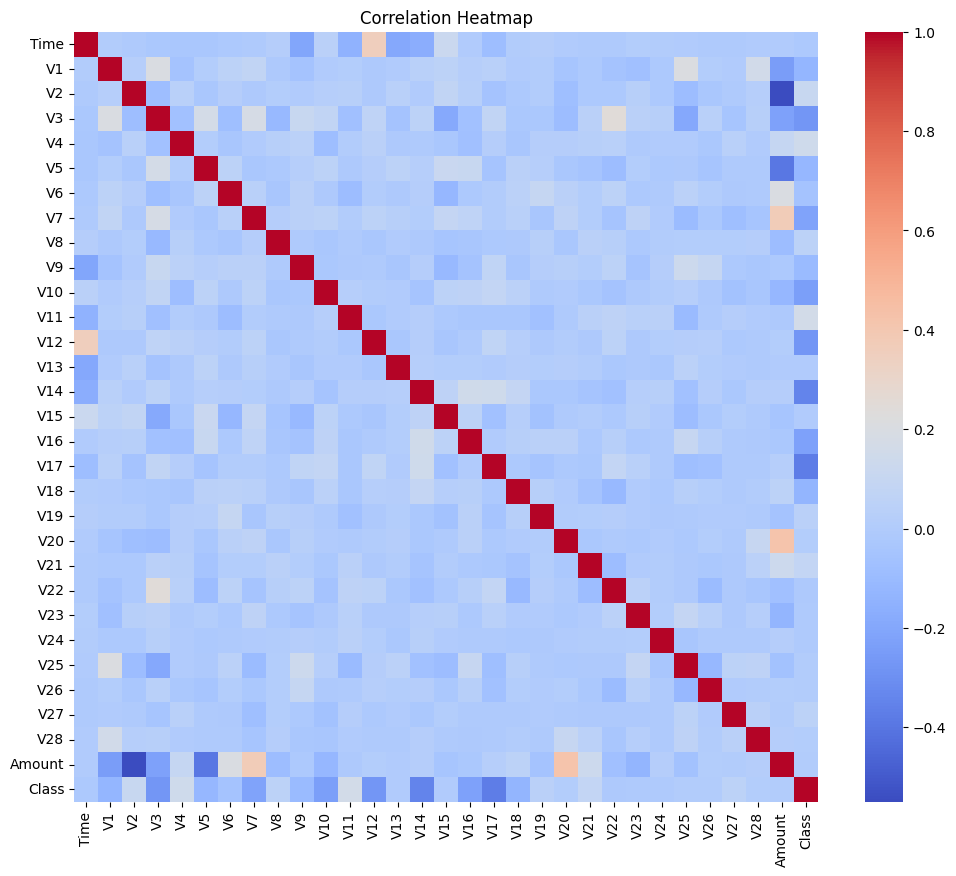


Logistic Regression
Accuracy : 0.998738544874411
Precision: 0.7368421052631579
Recall   : 0.5384615384615384
F1 Score : 0.6222222222222222

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     26901
         1.0       0.74      0.54      0.62        52

    accuracy                           1.00     26953
   macro avg       0.87      0.77      0.81     26953
weighted avg       1.00      1.00      1.00     26953


Decision Tree
Accuracy : 0.9991466627091604
Precision: 0.7735849056603774
Recall   : 0.7884615384615384
F1 Score : 0.780952380952381

Classification Report
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     26901
         1.0       0.77      0.79      0.78        52

    accuracy                           1.00     26953
   macro avg       0.89      0.89      0.89     26953
weighted avg       1.00      1.00      1.00     26953


Neural Network
Accuracy :

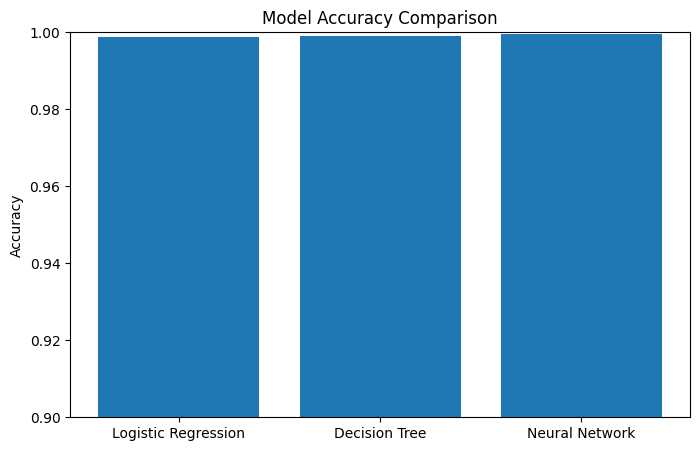

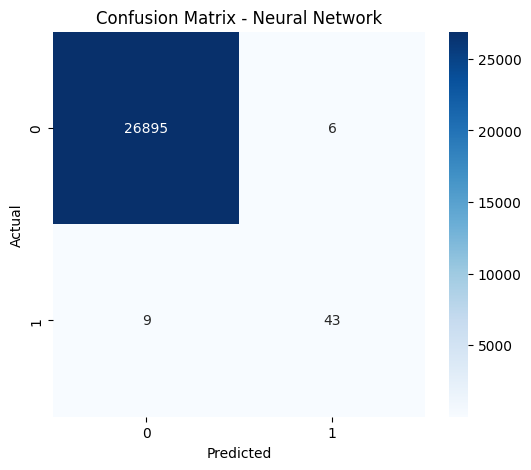

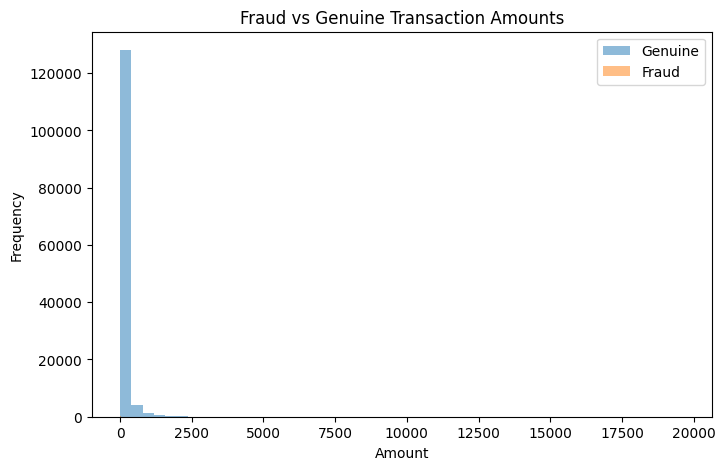


Sample Prediction:
Legitimate Transaction

Project Completed Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("/content/creditcard.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# Remove rows with any missing values
df.dropna(inplace=True)

print("\nDataset Shape after dropping NaNs:", df.shape)
print("\nMissing Values after dropping NaNs:")
print(df.isnull().sum())

print("\nClass Distribution")
print(df['Class'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Class (0=Genuine, 1=Fraud)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

plt.figure(figsize=(12,10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

df['Amount_Log'] = np.log1p(df['Amount'])

X = df.drop(['Class'], axis=1)
y = df['Class']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(100,50),
        max_iter=100,
        random_state=42
    )
}

results = {}

for name, model in models.items():

    print("\n" + "="*60)
    print(name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = accuracy

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)
print("Accuracy:", results[best_model_name])

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.9,1.0)
plt.show()

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    })

    importance = importance.sort_values(
        by='Importance',
        ascending=False
    )

    plt.figure(figsize=(10,8))

    sns.barplot(
        x='Importance',
        y='Feature',
        data=importance.head(15)
    )

    plt.title("Top 15 Important Features")
    plt.show()

fraud_data = df[df['Class'] == 1]
genuine_data = df[df['Class'] == 0]

plt.figure(figsize=(8,5))
plt.hist(
    genuine_data['Amount'],
    bins=50,
    alpha=0.5,
    label='Genuine'
)

plt.hist(
    fraud_data['Amount'],
    bins=50,
    alpha=0.5,
    label='Fraud'
)

plt.legend()
plt.title("Fraud vs Genuine Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

def detect_fraud(transaction):

    transaction = np.array(transaction).reshape(1,-1)

    transaction = scaler.transform(transaction)

    prediction = best_model.predict(transaction)

    if prediction[0] == 1:
        return "Fraudulent Transaction"
    else:
        return "Legitimate Transaction"

sample_transaction = X.iloc[0].values

print("\nSample Prediction:")
print(detect_fraud(sample_transaction))

print("\nProject Completed Successfully")